# Week 1 Notebook：微电网静态安全预测导论与 pandapower 入门

**课程项目：** Physics-informed AI for three-phase unbalanced N-1 security screening in microgrids  
**本周目标：** 先用一个 balanced single-phase-equivalent 小系统建立可复现、可验证的 pandapower 潮流工作流。

> 说明：Week 1 暂时不使用三相不平衡潮流。我们先用 `pp.runpp()` 熟悉 pandapower 的建模、结果表、功率平衡检查、线路电流检查和场景交叉验证。Week 2 会切换到 `runpp_3ph()`、`asymmetric_load`、`asymmetric_sgen` 和三相结果表。

本 notebook 不只是“跑通代码”，还包含三类验证：

1. **结构验证**：网络拓扑、设备连接、参数范围是否合理。
2. **物理验证**：功率平衡、线路电流与 loading 公式是否一致。
3. **交叉验证**：不同求解器、不同场景趋势、base case 是否被场景循环污染。

## 0. 环境与安装

如果环境中没有安装 pandapower，可以在终端或 notebook 中执行：

```bash
pip install pandapower
```

建议版本：`pandapower >= 3.4.0`。本 notebook 在小系统上运行很快，适合课堂演示和学生自学。

In [1]:
from __future__ import annotations

import copy
from pathlib import Path
from typing import Any, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pandapower as pp

from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"pandapower version: {pp.__version__}")
print(f"numpy version:      {np.__version__}")
print(f"pandas version:     {pd.__version__}")

pandapower version: 3.4.0
numpy version:      2.3.5
pandas version:     2.3.3


## 1. Week 1 的工程故事

我们最终要做的是：

\[
(x_t, c, G) \longrightarrow \Pr(\text{static violation}),\quad s(x_t,c),\quad \text{top-k risky contingencies}
\]

其中：

- \(x_t\)：微电网运行状态，例如负荷、PV、BESS、PCC 状态；
- \(c\)：候选 N-1 contingency，例如线路退出、DER trip、PCC outage；
- \(G\)：电网拓扑和设备参数；
- 输出是 violation probability、severity 和高风险 contingency 排序。

本周先把一个最小的 balanced 潮流仿真链路做扎实：

```text
建网 -> 运行潮流 -> 检查物理一致性 -> 构造场景 -> 导出 summary
```

## 2. 安全阈值与工具函数

Week 1 使用最简单的静态安全阈值：

\[
0.95 \le V_i \le 1.05,\qquad \text{line loading} \le 100\%,\qquad \text{trafo loading} \le 100\%.
\]

这不是说所有配电系统都必须用这组阈值，而是为了让学生先掌握 label 与 severity 的基本逻辑。

In [2]:
VM_MIN_PU = 0.95
VM_MAX_PU = 1.05
LOADING_MAX_PERCENT = 100.0

OUTPUT_DIR = Path("week1_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def print_section(title: str) -> None:
    """Simple console divider for notebook readability."""
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

## 3. 构建一个 microgrid-like balanced feeder

这个小系统包含：

- 一个上级电网 `ext_grid`；
- 一个 MV feeder 和一个 20/0.4 kV 变压器；
- 一个低压径向 feeder；
- EV load、flexible building load、critical load；
- 一个 PV `sgen`；
- 一个 BESS `storage`。

注意：这里的模型是 **balanced single-phase-equivalent**，因此每个 load/PV/BESS 都是三相等效量。三相不平衡将在 Week 2 处理。

In [3]:
def build_week1_microgrid() -> pp.pandapowerNet:
    """Build a small balanced microgrid-like radial feeder for Week 1.

    Modeling notes
    --------------
    - This is a single-phase-equivalent balanced model.
    - It is deliberately small so students can inspect every table manually.
    - The system contains a PCC-like MV bus, a distribution transformer,
      LV feeder buses, loads, PV, and BESS.
    """
    net = pp.create_empty_network(sn_mva=1.0, f_hz=50.0, name="week1_balanced_microgrid")

    # Buses
    b_grid = pp.create_bus(net, vn_kv=20.0, name="Utility grid bus")
    b_pcc = pp.create_bus(net, vn_kv=20.0, name="PCC / MV bus")
    b_lv0 = pp.create_bus(net, vn_kv=0.4, name="LV main bus")
    b_lv1 = pp.create_bus(net, vn_kv=0.4, name="LV feeder bus 1")
    b_lv2 = pp.create_bus(net, vn_kv=0.4, name="LV feeder bus 2")
    b_lv3 = pp.create_bus(net, vn_kv=0.4, name="LV feeder bus 3")
    b_lv4 = pp.create_bus(net, vn_kv=0.4, name="LV critical bus 4")

    # External grid and a short MV connection to the PCC.
    pp.create_ext_grid(net, bus=b_grid, vm_pu=1.02, va_degree=0.0, name="Upstream grid")
    pp.create_line_from_parameters(
        net, from_bus=b_grid, to_bus=b_pcc, length_km=1.0,
        r_ohm_per_km=0.206, x_ohm_per_km=0.080, c_nf_per_km=210.0,
        max_i_ka=0.40, name="MV feeder to PCC"
    )

    # A distribution transformer. Parameters are simple and transparent for teaching.
    pp.create_transformer_from_parameters(
        net, hv_bus=b_pcc, lv_bus=b_lv0, sn_mva=0.63,
        vn_hv_kv=20.0, vn_lv_kv=0.4,
        vk_percent=6.0, vkr_percent=1.0,
        pfe_kw=1.2, i0_percent=0.3, shift_degree=0.0,
        name="20/0.4 kV microgrid transformer"
    )

    # LV radial feeder. The values are representative and keep the example stable.
    lv_line_params = dict(
        r_ohm_per_km=0.642, x_ohm_per_km=0.083, c_nf_per_km=210.0,
        max_i_ka=0.30
    )
    pp.create_line_from_parameters(net, b_lv0, b_lv1, length_km=0.03, name="LV cable 0-1", **lv_line_params)
    pp.create_line_from_parameters(net, b_lv1, b_lv2, length_km=0.05, name="LV cable 1-2", **lv_line_params)
    pp.create_line_from_parameters(net, b_lv2, b_lv3, length_km=0.06, name="LV cable 2-3", **lv_line_params)
    pp.create_line_from_parameters(net, b_lv3, b_lv4, length_km=0.04, name="LV cable 3-4", **lv_line_params)

    # Loads and DERs. Names are used later by scenario functions.
    pp.create_load(net, bus=b_lv2, p_mw=0.020, q_mvar=0.008, name="EV charging load")
    pp.create_load(net, bus=b_lv3, p_mw=0.040, q_mvar=0.014, name="Flexible building load")
    pp.create_load(net, bus=b_lv4, p_mw=0.030, q_mvar=0.010, name="Critical load")
    pp.create_sgen(net, bus=b_lv3, p_mw=0.030, q_mvar=0.000, name="Rooftop PV")

    # Storage convention in pandapower:
    # p_mw > 0 means charging / consuming; p_mw < 0 means discharging / injecting.
    pp.create_storage(
        net, bus=b_lv4, p_mw=0.000, q_mvar=0.000,
        max_e_mwh=0.20, sn_mva=0.08, soc_percent=60.0,
        name="Battery energy storage system"
    )

    return net


net = build_week1_microgrid()
print(net)

This pandapower network includes the following parameter tables:
   - bus (7 elements)
   - load (3 elements)
   - sgen (1 element)
   - storage (1 element)
   - ext_grid (1 element)
   - line (5 elements)
   - trafo (1 element)


## 4. 检查输入表

pandapower 的 `net` 本质上是一个由 DataFrame 组成的数据结构。我们先查看关键输入表。

In [4]:
def show_table(net: pp.pandapowerNet, table_name: str, columns: list[str] | None = None) -> None:
    """Display selected columns of a pandapower table."""
    table = getattr(net, table_name)
    print_section(f"net.{table_name}")
    if len(table) == 0:
        print("<empty>")
        return
    if columns is None:
        display(table)
    else:
        display(table[columns])

show_table(net, "bus", ["name", "vn_kv", "in_service"])
show_table(net, "line", ["name", "from_bus", "to_bus", "length_km", "r_ohm_per_km", "x_ohm_per_km", "max_i_ka"])
show_table(net, "trafo", ["name", "hv_bus", "lv_bus", "sn_mva", "vn_hv_kv", "vn_lv_kv", "vk_percent", "vkr_percent"])
show_table(net, "load", ["name", "bus", "p_mw", "q_mvar", "scaling", "in_service"])
show_table(net, "sgen", ["name", "bus", "p_mw", "q_mvar", "scaling", "in_service"])
show_table(net, "storage", ["name", "bus", "p_mw", "q_mvar", "sn_mva", "max_e_mwh", "soc_percent", "in_service"])


net.bus


,name,vn_kv,in_service
0,Utility grid bus,20.0,True
1,PCC / MV bus,20.0,True
2,LV main bus,0.4,True
3,LV feeder bus 1,0.4,True
4,LV feeder bus 2,0.4,True
5,LV feeder bus 3,0.4,True
6,LV critical bus 4,0.4,True



net.line


,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,max_i_ka
0,MV feeder to PCC,0,1,1.00,0.206,0.080,0.4
1,LV cable 0-1,2,3,0.03,0.642,0.083,0.3
2,LV cable 1-2,3,4,0.05,0.642,0.083,0.3
3,LV cable 2-3,4,5,0.06,0.642,0.083,0.3
4,LV cable 3-4,5,6,0.04,0.642,0.083,0.3



net.trafo


...

,name,bus,p_mw,q_mvar,scaling,in_service
0,EV charging load,4,0.02,0.008,1.0,True
1,Flexible building load,5,0.04,0.014,1.0,True
2,Critical load,6,0.03,0.010,1.0,True



net.sgen


,name,bus,p_mw,q_mvar,scaling,in_service
0,Rooftop PV,5,0.03,0.0,1.0,True



net.storage


,name,bus,p_mw,q_mvar,sn_mva,max_e_mwh,soc_percent,in_service
0,Battery energy storage system,6,0.0,0.0,0.08,0.2,60.0,True


## 5. Proof 0：网络结构验证

先不运行潮流，先验证网络本身是否合理：

- bus/line/trafo 数量符合预期；
- 所有设备引用的 bus 都存在；
- 所有电压等级、线路长度、线路限值为正；
- 从 slack bus 到每个 bus 都连通；
- Week 1 设计为一个 radial tree。

In [5]:
def validate_network_structure(net: pp.pandapowerNet) -> None:
    """Validate topology and basic input parameters before running power flow."""
    assert len(net.bus) == 7, "Unexpected number of buses. Did the Week 1 network change?"
    assert len(net.line) == 5, "Unexpected number of lines."
    assert len(net.trafo) == 1, "Unexpected number of transformers."
    assert len(net.ext_grid) == 1, "Use exactly one upstream grid/slack source in Week 1."
    assert (net.bus.vn_kv > 0).all(), "All buses must have positive rated voltage."
    assert (net.line.length_km > 0).all(), "All line lengths must be positive."
    assert (net.line.max_i_ka > 0).all(), "All lines must have positive current ratings."
    assert (net.load.p_mw >= 0).all(), "Loads should be non-negative in this balanced teaching model."
    assert (net.sgen.p_mw >= 0).all(), "Static generators should have non-negative active generation."

    bus_index = set(net.bus.index)
    references = {
        "line.from_bus": set(net.line.from_bus.astype(int)),
        "line.to_bus": set(net.line.to_bus.astype(int)),
        "trafo.hv_bus": set(net.trafo.hv_bus.astype(int)),
        "trafo.lv_bus": set(net.trafo.lv_bus.astype(int)),
        "load.bus": set(net.load.bus.astype(int)),
        "sgen.bus": set(net.sgen.bus.astype(int)),
        "storage.bus": set(net.storage.bus.astype(int)),
        "ext_grid.bus": set(net.ext_grid.bus.astype(int)),
    }
    for name, buses in references.items():
        missing = buses - bus_index
        assert not missing, f"{name} references missing buses: {missing}"

    # Graph connectivity check.
    G = nx.Graph()
    G.add_nodes_from(net.bus.index.tolist())
    for _, row in net.line[net.line.in_service].iterrows():
        G.add_edge(int(row.from_bus), int(row.to_bus), element="line")
    for _, row in net.trafo[net.trafo.in_service].iterrows():
        G.add_edge(int(row.hv_bus), int(row.lv_bus), element="trafo")

    slack_bus = int(net.ext_grid.bus.iloc[0])
    for bus in net.bus.index:
        assert nx.has_path(G, slack_bus, int(bus)), f"Bus {bus} is not connected to the slack bus."
    assert nx.is_tree(G), "Week 1 example is intended to be a radial tree."

    print("Network structure check passed.")


validate_network_structure(net)

Network structure check passed.


## 6. 运行 base-case balanced power flow

`pp.runpp()` 会把结果写入 `net.res_bus`、`net.res_line`、`net.res_trafo` 等结果表。

这里我们明确设置：

- `algorithm="nr"`：Newton-Raphson；
- `init="flat"`：平坦启动，便于教学复现；
- `tolerance_mva=1e-9`：较严格的收敛容差；
- `trafo_loading="current"`：用电流计算变压器 loading。

In [6]:
def run_balanced_pf(net: pp.pandapowerNet, algorithm: str = "nr", init: str = "flat") -> None:
    """Run a balanced AC power flow and assert convergence."""
    pp.runpp(
        net,
        algorithm=algorithm,
        init=init,
        calculate_voltage_angles=False,
        tolerance_mva=1e-9,
        max_iteration=100,
        numba=False,
        trafo_loading="current",
    )
    assert bool(net.converged), f"Power flow did not converge with algorithm={algorithm}"


run_balanced_pf(net)
print(f"Converged: {net.converged}")

Converged: True


## 7. 查看结果表

先观察电压、线路潮流、变压器 loading 和外部电网交换功率。

In [7]:
show_table(net, "res_bus")
show_table(net, "res_line")
show_table(net, "res_trafo")
show_table(net, "res_ext_grid")
show_table(net, "res_load")
show_table(net, "res_sgen")
show_table(net, "res_storage")


net.res_bus


,vm_pu,va_degree,p_mw,q_mvar
0,1.020000,0.000000,-0.063564,-0.006806
1,1.019964,-0.000118,0.000000,0.000000
2,1.015914,-0.297534,0.000000,0.000000
3,1.008048,-0.134276,0.000000,0.000000
4,0.994958,0.143559,0.020000,0.008000
5,0.984364,0.408734,0.010000,0.014000
6,0.979234,0.467132,0.030000,0.010000



net.res_line


,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,0.063564,0.006806,-0.063562,-0.034260,0.000002,-0.027454,0.001809,0.002044,0.002044,1.020000,0.000000,1.019964,-0.000118,0.510907
1,0.062241,0.032288,-0.061667,-0.032214,0.000573,0.000074,0.099620,0.099620,0.099620,1.015914,-0.297534,1.008048,-0.134276,33.206745
2,0.061667,0.032214,-0.060712,-0.032091,0.000956,0.000123,0.099620,0.099621,0.099621,1.008048,-0.134276,0.994958,0.143559,33.206863
3,0.040712,0.024091,-0.040167,-0.024021,0.000544,0.000070,0.068626,0.068626,0.068626,0.994958,0.143559,0.984364,0.408734,22.875359
4,0.030167,0.010021,-0.030000,-0.010000,0.000167,0.000021,0.046611,0.046611,0.046611,0.984364,0.408734,0.979234,0.467132,15.537154



net.res_trafo


...

,p_mw,q_mvar
0,0.02,0.008
1,0.04,0.014
2,0.03,0.010



net.res_sgen


,p_mw,q_mvar
0,0.03,0.0



net.res_storage


,p_mw,q_mvar
0,0.0,0.0


## 8. Proof 1：系统级功率平衡验证

对一个收敛的潮流解，系统级有功功率应满足：

\[
P_{\mathrm{ext}} + P_{\mathrm{sgen}}
= P_{\mathrm{load}} + P_{\mathrm{storage}} + P_{\mathrm{loss}}.
\]

等价写成 residual：

\[
\epsilon_P
= P_{\mathrm{ext}} - \left(P_{\mathrm{load}}+P_{\mathrm{storage}}-P_{\mathrm{sgen}}+P_{\mathrm{line\ loss}}+P_{\mathrm{trafo\ loss}}\right)
\approx 0.
\]

这里的 storage 符号要特别注意：`storage.p_mw > 0` 表示充电，即等效负荷；`storage.p_mw < 0` 表示放电，即等效发电。

In [8]:
def audit_power_balance(net: pp.pandapowerNet, atol_mw: float = 1e-5, verbose: bool = True) -> Dict[str, float]:
    """Check aggregate P/Q consistency using pandapower result tables.

    Active power convention used here:
        ext_grid + sgen = load + storage + line_losses + trafo_losses

    Therefore:
        residual = ext_grid - (load + storage - sgen + losses)
    """
    p_ext = float(net.res_ext_grid.p_mw.sum()) if len(net.res_ext_grid) else 0.0
    q_ext = float(net.res_ext_grid.q_mvar.sum()) if len(net.res_ext_grid) else 0.0
    p_load = float(net.res_load.p_mw.sum()) if len(net.res_load) else 0.0
    q_load = float(net.res_load.q_mvar.sum()) if len(net.res_load) else 0.0
    p_sgen = float(net.res_sgen.p_mw.sum()) if len(net.res_sgen) else 0.0
    q_sgen = float(net.res_sgen.q_mvar.sum()) if len(net.res_sgen) else 0.0
    p_storage = float(net.res_storage.p_mw.sum()) if hasattr(net, "res_storage") and len(net.res_storage) else 0.0
    q_storage = float(net.res_storage.q_mvar.sum()) if hasattr(net, "res_storage") and len(net.res_storage) else 0.0
    p_line_loss = float(net.res_line.pl_mw.sum()) if len(net.res_line) else 0.0
    q_line_loss = float(net.res_line.ql_mvar.sum()) if len(net.res_line) else 0.0
    p_trafo_loss = float(net.res_trafo.pl_mw.sum()) if len(net.res_trafo) else 0.0
    q_trafo_loss = float(net.res_trafo.ql_mvar.sum()) if len(net.res_trafo) else 0.0

    p_expected_ext = p_load + p_storage - p_sgen + p_line_loss + p_trafo_loss
    q_expected_ext = q_load + q_storage - q_sgen + q_line_loss + q_trafo_loss
    p_residual = p_ext - p_expected_ext
    q_residual = q_ext - q_expected_ext

    audit = {
        "p_ext_mw": p_ext,
        "p_load_mw": p_load,
        "p_sgen_mw": p_sgen,
        "p_storage_mw": p_storage,
        "p_line_loss_mw": p_line_loss,
        "p_trafo_loss_mw": p_trafo_loss,
        "p_expected_ext_mw": p_expected_ext,
        "p_balance_residual_mw": p_residual,
        "q_ext_mvar": q_ext,
        "q_expected_ext_mvar": q_expected_ext,
        "q_balance_residual_mvar": q_residual,
    }
    if verbose:
        display(pd.Series(audit).to_frame("value"))

    assert abs(p_residual) <= atol_mw, f"P balance residual too large: {p_residual:.3e} MW"
    assert abs(q_residual) <= 5e-5, f"Q balance residual too large: {q_residual:.3e} Mvar"
    return audit


balance_audit = audit_power_balance(net)
print("Power balance check passed.")

,value
p_ext_mw,6.356386e-02
p_load_mw,9.000000e-02
p_sgen_mw,3.000000e-02
p_storage_mw,0.000000e+00
p_line_loss_mw,2.242939e-03
p_trafo_loss_mw,1.320916e-03
p_expected_ext_mw,6.356386e-02
p_balance_residual_mw,-4.608686e-11
q_ext_mvar,6.806009e-03
q_expected_ext_mvar,6.806009e-03


Power balance check passed.


## 9. Proof 2：线路 loading 公式验证

pandapower 的线路 loading 可以用以下公式独立重算：

\[
\text{loading}_\ell = 100 \times \frac{\max(|I_{from}|,|I_{to}|)}{I_{max}\cdot df\cdot parallel}.
\]

这一步可以发现线路限流参数、derating factor 或 parallel 参数的使用错误。

In [9]:
def audit_line_loading_formula(net: pp.pandapowerNet, atol_percent: float = 1e-9) -> pd.DataFrame:
    """Recompute line loading from terminal current and current limit."""
    i_limit = net.line.max_i_ka.astype(float) * net.line.df.astype(float) * net.line.parallel.astype(float)
    i_terminal = np.maximum(net.res_line.i_from_ka.abs(), net.res_line.i_to_ka.abs())
    manual = 100.0 * i_terminal / i_limit

    out = pd.DataFrame({
        "line_name": net.line.name,
        "i_from_ka": net.res_line.i_from_ka,
        "i_to_ka": net.res_line.i_to_ka,
        "i_limit_ka": i_limit,
        "manual_loading_percent": manual,
        "pandapower_loading_percent": net.res_line.loading_percent,
    })
    out["absolute_error_percent"] = (out.manual_loading_percent - out.pandapower_loading_percent).abs()
    max_err = float(out.absolute_error_percent.max())
    assert max_err <= atol_percent, f"Manual line loading check failed: max error={max_err:.3e}%"
    return out


loading_check = audit_line_loading_formula(net)
display(loading_check)
print("Line loading formula check passed.")

,line_name,i_from_ka,i_to_ka,i_limit_ka,manual_loading_percent,pandapower_loading_percent,absolute_error_percent
0,MV feeder to PCC,0.001809,0.002044,0.4,0.510907,0.510907,0.000000e+00
1,LV cable 0-1,0.099620,0.099620,0.3,33.206745,33.206745,7.105427e-15
2,LV cable 1-2,0.099620,0.099621,0.3,33.206863,33.206863,0.000000e+00
3,LV cable 2-3,0.068626,0.068626,0.3,22.875359,22.875359,3.552714e-15
4,LV cable 3-4,0.046611,0.046611,0.3,15.537154,15.537154,0.000000e+00


Line loading formula check passed.


## 10. Proof 3：用 \(S=\sqrt{3}VI\) 独立重算线路电流

对于 balanced 三相等效潮流，端口视在功率和线电压满足：

\[
|S|=\sqrt{3}V_{LL}|I|.
\]

因此可以从 `res_line.p_from_mw`、`res_line.q_from_mvar` 和 bus 电压独立重算 `i_from_ka`，再与 pandapower 结果对比。

In [10]:
def audit_line_current_from_power(net: pp.pandapowerNet, atol_ka: float = 1e-8) -> pd.DataFrame:
    """Recompute line terminal currents from P/Q and bus voltages.

    Units are convenient here:
    - S in MVA
    - V_LL in kV
    - I in kA
    because 1 MVA / 1 kV = 1 kA.
    """
    from_buses = net.line.from_bus.astype(int).values
    to_buses = net.line.to_bus.astype(int).values
    v_from_kv = net.res_bus.vm_pu.loc[from_buses].values * net.bus.vn_kv.loc[from_buses].values
    v_to_kv = net.res_bus.vm_pu.loc[to_buses].values * net.bus.vn_kv.loc[to_buses].values

    s_from_mva = np.hypot(net.res_line.p_from_mw.values, net.res_line.q_from_mvar.values)
    s_to_mva = np.hypot(net.res_line.p_to_mw.values, net.res_line.q_to_mvar.values)
    i_from_calc = s_from_mva / (np.sqrt(3.0) * v_from_kv)
    i_to_calc = s_to_mva / (np.sqrt(3.0) * v_to_kv)

    out = pd.DataFrame({
        "line_name": net.line.name,
        "i_from_calc_ka": i_from_calc,
        "i_from_pp_ka": net.res_line.i_from_ka.values,
        "i_to_calc_ka": i_to_calc,
        "i_to_pp_ka": net.res_line.i_to_ka.values,
    })
    out["from_abs_error_ka"] = (out.i_from_calc_ka - out.i_from_pp_ka).abs()
    out["to_abs_error_ka"] = (out.i_to_calc_ka - out.i_to_pp_ka).abs()
    max_err = max(float(out.from_abs_error_ka.max()), float(out.to_abs_error_ka.max()))
    assert max_err <= atol_ka, f"Line current formula check failed: max error={max_err:.3e} kA"
    return out


current_check = audit_line_current_from_power(net)
display(current_check)
print("Line current from S=sqrt(3)VI check passed.")

,line_name,i_from_calc_ka,i_from_pp_ka,i_to_calc_ka,i_to_pp_ka,from_abs_error_ka,to_abs_error_ka
0,MV feeder to PCC,0.001809,0.001809,0.002044,0.002044,2.168404e-19,0.000000e+00
1,LV cable 0-1,0.099620,0.099620,0.099620,0.099620,1.387779e-17,1.387779e-17
2,LV cable 1-2,0.099620,0.099620,0.099621,0.099621,2.775558e-17,0.000000e+00
3,LV cable 2-3,0.068626,0.068626,0.068626,0.068626,0.000000e+00,0.000000e+00
4,LV cable 3-4,0.046611,0.046611,0.046611,0.046611,0.000000e+00,6.938894e-18


Line current from S=sqrt(3)VI check passed.


## 11. 生成 base-case 静态安全摘要

这里的 `violation_flag` 包含：

- 电压越限；
- 线路 loading 超过 100%；
- 变压器 loading 超过 100%。

Week 4 会把这个逻辑扩展为 N-1 后的标签。

In [11]:
def summarize_static_security(net: pp.pandapowerNet, scenario: str) -> Dict[str, Any]:
    """Extract static security metrics from a solved pandapower network."""
    assert bool(net.converged), "Cannot summarize a non-converged power flow."

    min_vm = float(net.res_bus.vm_pu.min())
    max_vm = float(net.res_bus.vm_pu.max())
    max_line_loading = float(net.res_line.loading_percent.max()) if len(net.res_line) else 0.0
    max_trafo_loading = float(net.res_trafo.loading_percent.max()) if len(net.res_trafo) else np.nan

    voltage_violation = (min_vm < VM_MIN_PU) or (max_vm > VM_MAX_PU)
    line_violation = max_line_loading > LOADING_MAX_PERCENT
    trafo_violation = max_trafo_loading > LOADING_MAX_PERCENT
    violation = voltage_violation or line_violation or trafo_violation

    return {
        "scenario": scenario,
        "converged": bool(net.converged),
        "total_load_mw": float(net.res_load.p_mw.sum()) if len(net.res_load) else 0.0,
        "pv_mw": float(net.res_sgen.p_mw.sum()) if len(net.res_sgen) else 0.0,
        "storage_p_mw": float(net.res_storage.p_mw.sum()) if len(net.res_storage) else 0.0,
        "grid_import_mw": float(net.res_ext_grid.p_mw.sum()) if len(net.res_ext_grid) else 0.0,
        "min_vm_pu": min_vm,
        "max_vm_pu": max_vm,
        "max_line_loading_percent": max_line_loading,
        "trafo_loading_percent": max_trafo_loading,
        "voltage_violation": bool(voltage_violation),
        "line_violation": bool(line_violation),
        "trafo_violation": bool(trafo_violation),
        "violation_flag": bool(violation),
    }


base_summary = summarize_static_security(net, "base")
display(pd.Series(base_summary).to_frame("base"))

,base
scenario,base
converged,True
total_load_mw,0.09
pv_mw,0.03
storage_p_mw,0.0
grid_import_mw,0.063564
min_vm_pu,0.979234
max_vm_pu,1.02
max_line_loading_percent,33.206863
trafo_loading_percent,11.237048


## 12. 可视化：电压 profile 与线路 loading

这两张图是后续论文中最常见的基础图表：

- voltage profile：看最低电压在哪里；
- line loading：看最接近热稳定限值的线路。

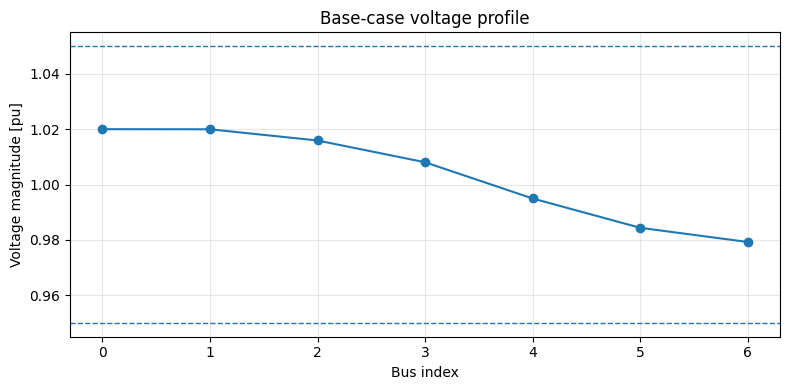

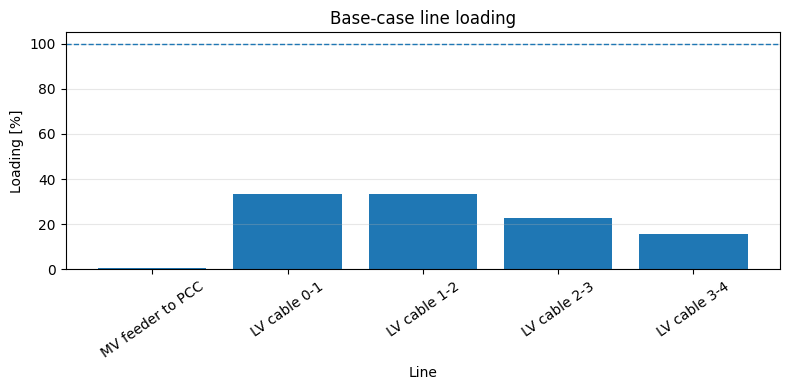

Saved: week1_outputs/week1_base_voltage_profile.png
Saved: week1_outputs/week1_base_line_loading.png


In [12]:
def plot_voltage_profile(net: pp.pandapowerNet, title: str = "Voltage profile") -> Path:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(net.res_bus.index, net.res_bus.vm_pu, marker="o")
    ax.axhline(VM_MIN_PU, linestyle="--", linewidth=1)
    ax.axhline(VM_MAX_PU, linestyle="--", linewidth=1)
    ax.set_xlabel("Bus index")
    ax.set_ylabel("Voltage magnitude [pu]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = OUTPUT_DIR / "week1_base_voltage_profile.png"
    fig.savefig(path, dpi=160)
    plt.show()
    return path


def plot_line_loading(net: pp.pandapowerNet, title: str = "Line loading") -> Path:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(net.line.name.astype(str), net.res_line.loading_percent)
    ax.axhline(LOADING_MAX_PERCENT, linestyle="--", linewidth=1)
    ax.set_xlabel("Line")
    ax.set_ylabel("Loading [%]")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    path = OUTPUT_DIR / "week1_base_line_loading.png"
    fig.savefig(path, dpi=160)
    plt.show()
    return path

voltage_fig = plot_voltage_profile(net, "Base-case voltage profile")
loading_fig = plot_line_loading(net, "Base-case line loading")
print(f"Saved: {voltage_fig}")
print(f"Saved: {loading_fig}")

## 13. 构造运行场景

AI 安全预测不是从一个 operating point 学习，而是从很多 operating scenarios 学习。

Week 1 先定义 6 个场景：

1. base；
2. morning low PV；
3. noon high PV；
4. evening peak with BESS discharge；
5. BESS charging peak；
6. stress high load charging。

这些场景可以帮助学生理解：负荷、PV 和 BESS 改变会如何影响电压、loading 和 PCC 功率交换。

In [13]:
def scenario_specs() -> pd.DataFrame:
    """Deterministic Week 1 scenarios."""
    return pd.DataFrame([
        {"scenario": "base", "load_scale": 1.00, "pv_scale": 1.00, "storage_p_mw": 0.000},
        {"scenario": "morning_low_pv", "load_scale": 0.75, "pv_scale": 0.30, "storage_p_mw": 0.000},
        {"scenario": "noon_high_pv", "load_scale": 0.80, "pv_scale": 2.00, "storage_p_mw": 0.000},
        {"scenario": "evening_peak_bess_discharge", "load_scale": 1.35, "pv_scale": 0.00, "storage_p_mw": -0.040},
        {"scenario": "bess_charging_peak", "load_scale": 1.25, "pv_scale": 0.20, "storage_p_mw": 0.050},
        {"scenario": "stress_high_load_charging", "load_scale": 2.00, "pv_scale": 0.00, "storage_p_mw": 0.040},
    ])


def apply_scenario(net: pp.pandapowerNet, row: pd.Series) -> None:
    """Apply load/PV/storage scenario to a copy of the base network."""
    net.load["scaling"] = float(row.load_scale)
    if len(net.sgen):
        net.sgen["scaling"] = float(row.pv_scale)
    if len(net.storage):
        net.storage.loc[:, "p_mw"] = float(row.storage_p_mw)
        net.storage.loc[:, "scaling"] = 1.0

scenario_df = scenario_specs()
display(scenario_df)

,scenario,load_scale,pv_scale,storage_p_mw
0,base,1.00,1.0,0.00
1,morning_low_pv,0.75,0.3,0.00
2,noon_high_pv,0.80,2.0,0.00
3,evening_peak_bess_discharge,1.35,0.0,-0.04
4,bess_charging_peak,1.25,0.2,0.05
5,stress_high_load_charging,2.00,0.0,0.04


## 14. 交叉验证 A：不同潮流求解器对比

在这个径向系统上，Newton-Raphson (`nr`) 和 backward/forward sweep (`bfsw`) 应该给出几乎相同的结果。

这不是所有系统都必须做的检查，但在课程初期非常有用：它能帮助发现网络参数、结果读取或求解设置错误。

In [14]:
def compare_solvers(net: pp.pandapowerNet, vm_atol_pu: float = 2e-3, loading_atol_percent: float = 1.0) -> Dict[str, float]:
    """Compare NR and BFSW solutions for the same scenario."""
    nr_net = copy.deepcopy(net)
    bfsw_net = copy.deepcopy(net)
    run_balanced_pf(nr_net, algorithm="nr", init="flat")
    run_balanced_pf(bfsw_net, algorithm="bfsw", init="flat")

    vm_diff = float((nr_net.res_bus.vm_pu - bfsw_net.res_bus.vm_pu).abs().max())
    loading_diff = float((nr_net.res_line.loading_percent - bfsw_net.res_line.loading_percent).abs().max())

    assert vm_diff <= vm_atol_pu, f"NR/BFSW voltage difference too large: {vm_diff:.3e} pu"
    assert loading_diff <= loading_atol_percent, f"NR/BFSW loading difference too large: {loading_diff:.3e}%"

    return {"max_vm_diff_pu": vm_diff, "max_line_loading_diff_percent": loading_diff}

solver_check_base = compare_solvers(net)
display(pd.Series(solver_check_base).to_frame("base_solver_cross_check"))
print("Solver cross-check passed for base case.")

,base_solver_cross_check
max_vm_diff_pu,5.048195e-11
max_line_loading_diff_percent,4.031734e-08


Solver cross-check passed for base case.


## 15. 运行所有场景并执行验证

对每个场景，我们执行：

1. `deepcopy(base_net)`，防止场景污染 base case；
2. 应用场景 scaling；
3. 运行 NR 潮流；
4. 物理检查：功率平衡、线路 loading、线路电流；
5. 求解器交叉验证：NR vs BFSW；
6. 提取静态安全 summary。

In [15]:
def run_scenario_suite(base_net: pp.pandapowerNet) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Run all deterministic Week 1 scenarios with validation."""
    validate_network_structure(base_net)
    summaries = []
    solver_checks = []

    original_snapshot = {
        "load_scaling": base_net.load.scaling.copy(),
        "sgen_scaling": base_net.sgen.scaling.copy() if len(base_net.sgen) else pd.Series(dtype=float),
        "storage_p_mw": base_net.storage.p_mw.copy() if len(base_net.storage) else pd.Series(dtype=float),
    }

    for _, row in scenario_specs().iterrows():
        scenario_net = copy.deepcopy(base_net)
        apply_scenario(scenario_net, row)
        run_balanced_pf(scenario_net, algorithm="nr", init="flat")

        audit_power_balance(scenario_net, verbose=False)
        audit_line_loading_formula(scenario_net)
        audit_line_current_from_power(scenario_net)

        check = compare_solvers(scenario_net)
        check["scenario"] = row.scenario
        solver_checks.append(check)

        summaries.append(summarize_static_security(scenario_net, row.scenario))

    # Ensure the original base network was not mutated by the scenario loop.
    assert base_net.load.scaling.equals(original_snapshot["load_scaling"]), "Base load scaling was mutated."
    if len(base_net.sgen):
        assert base_net.sgen.scaling.equals(original_snapshot["sgen_scaling"]), "Base sgen scaling was mutated."
    if len(base_net.storage):
        assert base_net.storage.p_mw.equals(original_snapshot["storage_p_mw"]), "Base storage setpoint was mutated."

    return pd.DataFrame(summaries), pd.DataFrame(solver_checks)

summary_df, solver_checks_df = run_scenario_suite(build_week1_microgrid())
print_section("Scenario summary")
display(summary_df)
print_section("Solver cross-checks")
display(solver_checks_df)

Network structure check passed.



Scenario summary


,scenario,converged,total_load_mw,pv_mw,storage_p_mw,grid_import_mw,min_vm_pu,max_vm_pu,max_line_loading_percent,trafo_loading_percent,voltage_violation,line_violation,trafo_violation,violation_flag
0,base,True,0.0900,0.030,0.00,0.063564,0.979234,1.02,33.206863,11.237048,False,False,False,False
1,morning_low_pv,True,0.0675,0.009,0.00,0.061776,0.981561,1.02,30.828887,10.440120,False,False,False,False
2,noon_high_pv,True,0.0720,0.060,0.00,0.013702,1.008746,1.02,13.485119,4.746423,False,False,False,False
3,evening_peak_bess_discharge,True,0.1215,0.000,-0.04,0.086821,0.970745,1.02,45.511515,15.295607,False,False,False,False
4,bess_charging_peak,True,0.1125,0.006,0.05,0.175014,0.904860,1.02,84.685655,28.184772,True,False,False,True
5,stress_high_load_charging,True,0.1800,0.000,0.04,0.257968,0.853761,1.02,126.177108,41.877499,True,True,False,True



Solver cross-checks


,max_vm_diff_pu,max_line_loading_diff_percent,scenario
0,5.048195e-11,4.031734e-08,base
1,8.572949e-10,6.416740e-07,morning_low_pv
2,8.332890e-12,1.087915e-08,noon_high_pv
3,3.260555e-10,2.986371e-07,evening_peak_bess_discharge
4,3.216687e-10,2.261009e-07,bess_charging_peak
5,5.609216e-10,4.065431e-07,stress_high_load_charging


## 16. 交叉验证 B：场景趋势检查

除了数学公式检查，还可以做工程常识检查：

- `stress_high_load_charging` 的 grid import 应明显高于 base；
- `noon_high_pv` 的 grid import 应低于 base；
- 高负荷/充电场景的最低电压应低于 base；
- `bess_charging_peak` 的 storage_p_mw 应为正。

这些检查不能证明模型“完全正确”，但能快速抓住 scaling 没生效、PV/负荷符号错误、BESS 符号错误等常见问题。

In [16]:
def validate_scenario_trends(summary_df: pd.DataFrame) -> None:
    """Engineering sanity checks across scenarios."""
    df = summary_df.set_index("scenario")
    base = df.loc["base"]
    stress = df.loc["stress_high_load_charging"]
    high_pv = df.loc["noon_high_pv"]
    charging = df.loc["bess_charging_peak"]

    assert stress.grid_import_mw > base.grid_import_mw, "Stress case should import more power than base."
    assert stress.min_vm_pu < base.min_vm_pu, "Stress case should have lower min voltage than base."
    assert stress.max_line_loading_percent > base.max_line_loading_percent, "Stress case should increase line loading."
    assert high_pv.grid_import_mw < base.grid_import_mw, "High PV case should reduce grid import."
    assert charging.storage_p_mw > 0, "BESS charging scenario should have positive storage p_mw."
    assert bool(summary_df.converged.all()), "All Week 1 scenarios are expected to converge."

    print("Scenario trend checks passed.")

validate_scenario_trends(summary_df)

Scenario trend checks passed.


## 17. 一键运行全部 Week 1 检查

教师或学生可以在作业提交前运行这个函数。只有全部检查通过，结果才建议用于报告或后续数据集生成。

In [17]:
def run_all_week1_checks() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Run the full Week 1 validation workflow."""
    base_net = build_week1_microgrid()
    validate_network_structure(base_net)
    run_balanced_pf(base_net, algorithm="nr", init="flat")
    audit_power_balance(base_net, verbose=False)
    audit_line_loading_formula(base_net)
    audit_line_current_from_power(base_net)
    compare_solvers(base_net)
    summary_df, solver_checks_df = run_scenario_suite(base_net)
    validate_scenario_trends(summary_df)
    print("All Week 1 checks passed.")
    return summary_df, solver_checks_df

summary_df, solver_checks_df = run_all_week1_checks()

Network structure check passed.

Network structure check passed.


Scenario trend checks passed.
All Week 1 checks passed.


## 18. 导出结果

这些文件可以直接用于 Week 1 作业，也可以作为后续 Week 2/3 的数据格式模板。

In [18]:
summary_path = OUTPUT_DIR / "week1_scenario_summary.csv"
solver_path = OUTPUT_DIR / "week1_solver_cross_checks.csv"
summary_df.to_csv(summary_path, index=False)
solver_checks_df.to_csv(solver_path, index=False)

print(f"Saved summary: {summary_path}")
print(f"Saved solver checks: {solver_path}")

Saved summary: week1_outputs/week1_scenario_summary.csv
Saved solver checks: week1_outputs/week1_solver_cross_checks.csv


## 19. 场景图表

下面画出所有场景的最低电压、最大线路 loading 和外部电网有功交换。

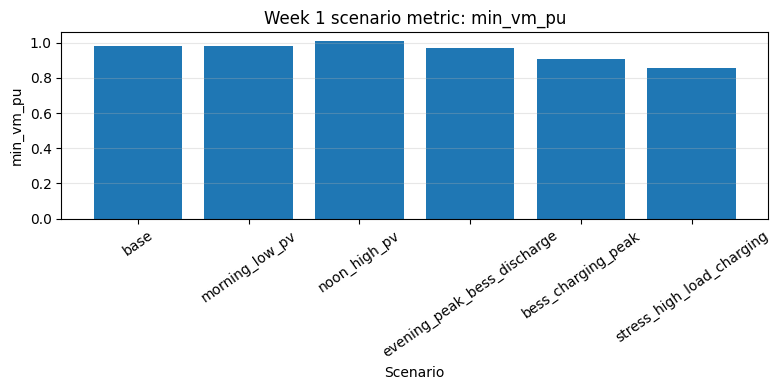

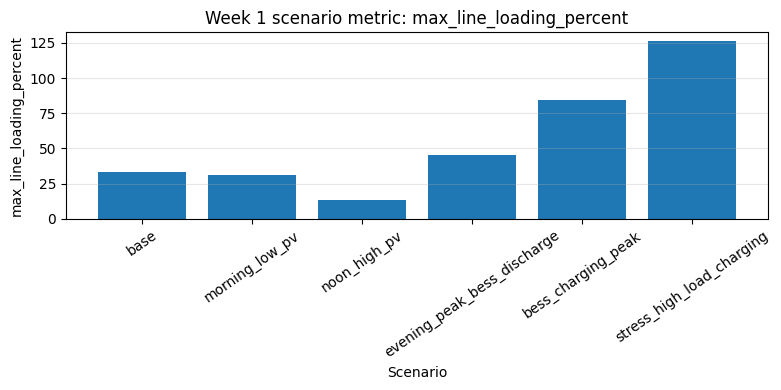

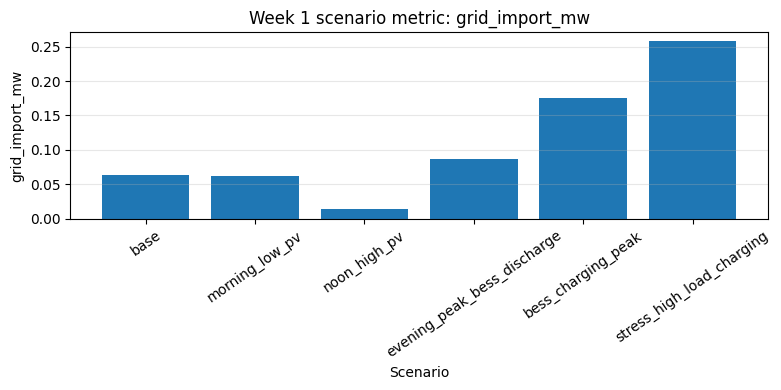

PosixPath('week1_outputs')

In [19]:
def plot_scenario_metrics(summary_df: pd.DataFrame) -> Path:
    metrics = ["min_vm_pu", "max_line_loading_percent", "grid_import_mw"]
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(summary_df["scenario"], summary_df[metric])
        ax.set_xlabel("Scenario")
        ax.set_ylabel(metric)
        ax.set_title(f"Week 1 scenario metric: {metric}")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        path = OUTPUT_DIR / f"week1_{metric}.png"
        fig.savefig(path, dpi=160)
        plt.show()
    return OUTPUT_DIR

plot_scenario_metrics(summary_df)

## 20. 课堂练习

### 练习 A：读懂输入表

1. 哪个 bus 是 PCC / MV bus？
2. 哪个 bus 是 LV critical bus？
3. PV 接在哪个 bus？BESS 接在哪个 bus？
4. 哪条 line 的 loading 最大？它为什么最大？

### 练习 B：新增一个场景

新建一个 `midday_export` 场景：

```text
load_scale = 0.65
pv_scale = 2.20
storage_p_mw = 0.040
```

问题：

1. grid import 是否会变成负数？
2. 最低电压和最高电压分别是多少？
3. 该场景是否出现静态安全 violation？
4. 你的场景是否通过 power balance、line current 和 solver cross-check？

In [20]:
# Exercise template: create and validate a new scenario.
# Uncomment and run after class discussion.

# exercise_net = build_week1_microgrid()
# custom_row = pd.Series({
#     "scenario": "midday_export",
#     "load_scale": 0.65,
#     "pv_scale": 2.20,
#     "storage_p_mw": 0.040,
# })
# apply_scenario(exercise_net, custom_row)
# run_balanced_pf(exercise_net)
# audit_power_balance(exercise_net)
# audit_line_loading_formula(exercise_net)
# audit_line_current_from_power(exercise_net)
# compare_solvers(exercise_net)
# display(pd.Series(summarize_static_security(exercise_net, "midday_export")).to_frame("midday_export"))

## 21. Week 1 作业提交要求

提交：

1. 已运行的 notebook，保留关键输出；
2. `week1_scenario_summary.csv`；
3. 一张 voltage profile 图和一张 line loading 图；
4. 300--500 字说明：哪个场景最接近安全边界？为什么？
5. 一个自定义场景，并说明它是否通过全部验证。

硬性要求：报告中使用的结果必须来自通过 `run_all_week1_checks()` 的模型。